#  Проект: Анализ сервиса аренды самокатов на основе статистического анализа данных.

**Описание задачи:**

Необходимо проанализировать данные о поездках пользователей сервиса аренды самокатов и проверить некоторые гипотезы, которые могут помочь бизнесу вырасти. А именно продакт-менеджеры сервиса хотят увеличить количество пользователей с подпиской. Для этого они будут проводить различные акции, но сначала нужно выяснить действительно ли пользователи с подпиской могут быть «выгоднее» для компании.
    
Для анализа были переданы 3 файла с данными о пользователях из нескольких городов, а также об их поездках за 2021 год.:

- данные о пользователях(ID, имя, возраст, город, тип подписки)

- данные о поездках (ID пользователя, расстояние одной поездки в метрах, время одной поездки в минутах, дата)

- информация о тарифах (тип подписки, стоимость одной минуты поездки по данной подписке, стоимость начала поездки, стоимость ежемесячного платежа)

     
Чтобы совершать поездки по городу, пользователи сервиса пользуются мобильным приложением. Сервисом можно пользоваться: 

1. без подписки

- абонентская плата отсутствует

- стоимость одной минуты поездки — 8 рублей

- стоимость старта (начала поездки) — 50 рублей

2. с подпиской Ultra

- абонентская плата — 199 рублей в месяц

- стоимость одной минуты поездки — 6 рублей

- стоимость старта — бесплатно
    
    

**Содержание работ:**

**1. Загрузка данных и изучение общей информации**

**2. Предобработка данных. Определение типов данных, наличие пропусков и дубликатов**

- Предобработка таблицы с данными о пользователях. Поиск дубликатов

- Предобработка таблицы с данными о поездках. Преобразование типа данных, поиск дубликатов.

**3. Исследовательский анализ данных. Описание общей информации о пользователях и поездках**

- Частота встречаемости городов

- Соотношение пользователей с подпиской и без подписки

- Возраст пользователей

- Расстояние, которое пользователь в среднем преодолевает за одну поездку

- Продолжительность поездок

**4. Объединение данных в один датафрейм и сравнение поездок пользователей обеих категорий**

- Создание датафрейм только с данными о пользователях с подпиской

- Создание датафрейм только с данными о пользователях без подписки

- Визуализация информации о расстоянии и времени поездок для пользователей обеих категорий.

**5. Проверка гипотез. Сравнение поездок с подпиской и без**

- Подсчёт выручки

- Проверка гипотезы. Пользователи с подпиской тратят больше времени на поездки

- Проверка гипотезы. Среднее расстояние поездки с подпиской не превышает точки износа самоката в 3130 м.

- Проверка гипотезы. Помесячная выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки.

**6. Расчеты для проведения маркетинговых мероприятий**

- Акция с раздачей промокодов
- Рассылка push-уведомлений

**7. Общие выводы**


In [1]:
# импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st
from scipy.stats import binom, norm
from math import sqrt


### Загрузка данных и изучение общей информации

In [2]:
# чтение файлов и сохранение в датафреймы
users, rides, subscriptions = (
    pd.read_csv('****'),  # данные о пользователях
    pd.read_csv('****'),  # данные о поездках
    pd.read_csv('****'),  # данные о подписках
)


In [3]:
print("Таблица с данными о пользователях")
users.head()

Таблица с данными о пользователях


,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [4]:
# краткий свод о таблице с данными о пользователях
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


In [5]:
print("Таблица с данными о поездках")
rides.head()

Таблица с данными о поездках


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


In [6]:
# краткий свод о таблице с данными о поездках
rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


In [7]:
print("Таблица с данными о подписках")
subscriptions.head()

Таблица с данными о подписках


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [8]:
# краткий свод о таблице c тарифами
subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


**Краткое резюме по загруженным данным:**

1. Таблица с данными о пользователях: 

- всего 1565 записей, пропусков не наблюдается, типы данных верные, названия столбцов стилистически верные.

2. Таблица с данными о поездках: 

- 18068 записей, пропусков не наблюдается, названия столбцов стилистически верные.

- колонку date необходимо привести к коректному типу данных. 

- в численных колонках distance и duration 6 знаков после запятой, следует округлить данные для дальнейшей обработки. Данные в колонке distance сократить до 2-ух знаков. Данные в колонке duration необходимо округлить до следующего целого числа.

3. Таблица с данными о тарифах:

- всего 2 записи, пропусков не наблюдается, типы данных верные, названия столбцов стилистически верные.</b></font><br>

### Предобработка данных

#### Предобработка таблицы с данными о пользователях

##### Поиск дубликатов 

In [9]:
# поиск явных дубликатов
users.duplicated().sum()

31

In [10]:
# удаление явных дубликатов
users=users.drop_duplicates()

In [11]:
# контроль обработки данных
users.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1534 entries, 0 to 1533
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1534 non-null   int64 
 1   name               1534 non-null   object
 2   age                1534 non-null   int64 
 3   city               1534 non-null   object
 4   subscription_type  1534 non-null   object
dtypes: int64(2), object(3)
memory usage: 71.9+ KB


In [12]:
# проверка неявных дубликатов в столбце с городами
users['city'].unique().tolist()

['Тюмень',
 'Омск',
 'Москва',
 'Ростов-на-Дону',
 'Краснодар',
 'Пятигорск',
 'Екатеринбург',
 'Сочи']

In [13]:
# проверка неявных дубликатов в столбце с видом подписки
users['subscription_type'].unique().tolist()

['ultra', 'free']

**В таблице с данными о пользователях были удалены 31 с явными дубликатами.**

**Невные дубликаты не обнаружены.**

#### Предобработка таблицы с данными о поездках

##### Приведение к верному типу данных

In [14]:
# преобразование типа данных столбца date
rides['date']=pd.to_datetime(rides['date'], format='%Y-%m-%d')

##### Поиск дубликатов 

In [15]:
# поиск явных дубликатов
rides.duplicated().sum()

0

**Дубликаты не обнаружены.**

##### Добавление столбца с номером месяца для дальнейшего анализа

In [16]:
# определение исследуемого периода
min_date = rides['date'].min()
max_date = rides['date'].max()
print(f"Минимальная дата: {min_date}")
print(f"Максимальная дата: {max_date}")

Минимальная дата: 2021-01-01 00:00:00
Максимальная дата: 2021-12-30 00:00:00


In [17]:
# Комментарий 
rides['date'].dt.year.unique()

array([2021])

**Данные о поездках представлены в рамках одного календарного года, значит, номер месяца можно определить без указания года.**

In [18]:
# создание солбца с номером месяца
rides['month']=rides['date'].dt.month

In [19]:
# контроль обработки данных
rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
 4   month     18068 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 705.9 KB


In [20]:
# контроль обработки данных
rides.head()

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


In [21]:
# Комментарий ревьюера
temp = rides.copy() # Создаем копию, что бы не изменять текущий датасет
display(temp['distance'].head(3))
# Округление расстояния
temp['distance'] = temp['distance'].round(2)
temp['distance'].head(3)

0    4409.919140
1    2617.592153
2     754.159807
Name: distance, dtype: float64

0    4409.92
1    2617.59
2     754.16
Name: distance, dtype: float64

##### Округление численных значений в колонке

In [22]:
# округление данных в колонке расстояние до 2-ух знаков после запятой
rides['distance'] = rides['distance'].round(2)

In [23]:
# округление данных в колонке время поездки до следующего целого числа
rides['duration']=np.ceil(rides['duration'])

**Краткое резюме по предобработке данных:**

1. Таблица с данными о пользователях: 

- обнаружены и удалены 31 явных дубликата
    
- неявные дубликаты не обнаружены

2. Таблица с данными о поездках: 

- колонка date преобразована к коректному типу данных date. 
    
- дубликаты не найдены

- колонку distance округлили до 2-ух знаков после запятой
    
- колонку duration округлили до следующего целого числа
    
- добавили новую колонку с номером месяца 

3. Таблица с данными о тарифах:

- каких либо преобразований не проводилось 

### Исследовательский анализ данных. Описание общей информации о пользователях и поездках.

#### Частота встречаемости городов

In [24]:
#  создание таблицы с долей присутствия городов
city=users['city'].value_counts().reset_index()
city['part']=round((city['city']/len(users))*100,2)
city.columns = ['city','count','percent']
city

,city,count,percent
0,Пятигорск,219,14.28
1,Екатеринбург,204,13.30
2,Ростов-на-Дону,198,12.91
3,Краснодар,193,12.58
4,Сочи,189,12.32
5,Омск,183,11.93
6,Тюмень,180,11.73
7,Москва,168,10.95


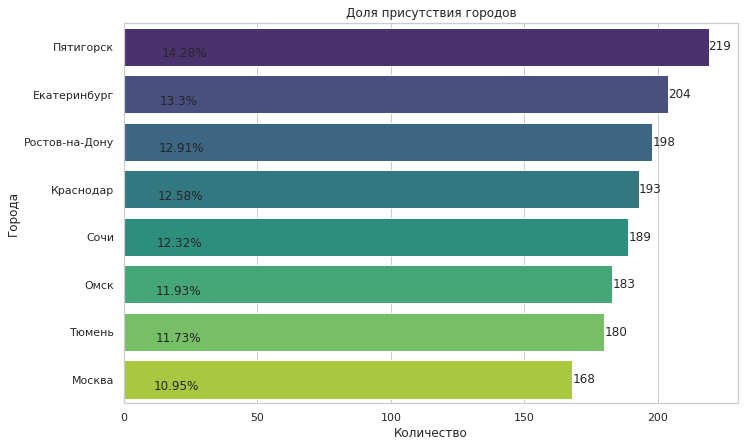

In [25]:
# Задаем размеры всех графиков
sns.set(rc={'figure.figsize':(11,7)})
# Настройка стиля seaborn
sns.set(style="whitegrid")

# Настройка графика
sns.barplot(x=city['count'], y=city['city'], palette="viridis")

# Добавляем подписи на график
for index, value in enumerate(city['count']):
    plt.text(value, index, str(value), va='center')  

# Добавляем подписи на график
for index, value in enumerate(city['percent']):
    plt.text(value, index, str(value)+'%', va='top') 

# Добавляем подписи на график    
plt.title('Доля присутствия городов')
plt.xlabel('Количество')
plt.ylabel('Города')
plt.show()

**Исследуемый сервис аренды самокатов присутствует в 8 городах.** 

**Всего 1534 уникальных пользователя зарегистрированно.**

**Долевое соотношение по кол-ву уникальных пользователей по городам распределено равномерно от 10,95% до 14,28%.**

**В тройку лидеров входят города: Пятигорск 14,28% , Екатеринбург 13,3%, Ростов-на Дону 12,91%. На последнем месте Москва с долей пользователей 10,95%.**

#### Соотношение пользователей с подпиской и без подписки

In [26]:
#  создание таблицы соотношения пользователей с подпиской и без 
subscriber=users['subscription_type'].value_counts().reset_index()
subscriber['part']=round((subscriber['subscription_type']/len(users))*100,2)
subscriber.columns = ['subscription_type','count','percent']
subscriber

,subscription_type,count,percent
0,free,835,54.43
1,ultra,699,45.57


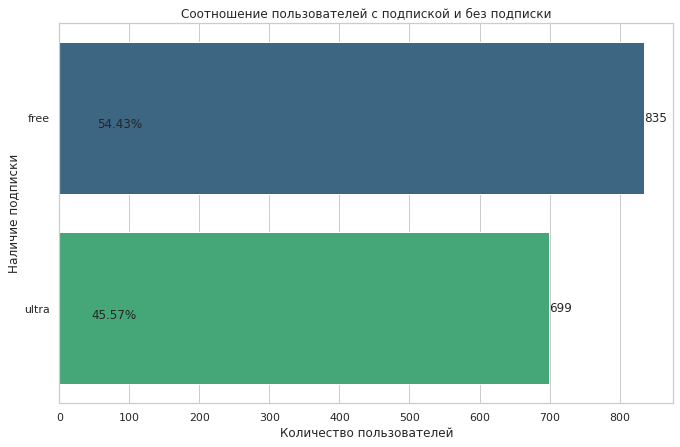

In [27]:
# Настройка графика
sns.barplot(x=subscriber['count'], y=subscriber['subscription_type'], palette="viridis")

# Добавляем подписи на график
for index, value in enumerate(subscriber['count']):
    plt.text(value, index, str(value), va='center')  

# Добавляем подписи на график
for index, value in enumerate(subscriber['percent']):
    plt.text(value, index, str(value)+'%', va='top') 
    
# Добавляем подписи на график    
plt.title('Cоотношение пользователей с подпиской и без подписки')
plt.xlabel('Количество пользователей')
plt.ylabel('Наличие подписки')
plt.show()

In [28]:
print('Доля  пользователей без подписки free',subscriber.loc[0,'percent'], '% превышает на',
      subscriber.loc[0,'percent' ]-subscriber.loc[1,'percent'],'% долю пользователей с подпиской ultra',
      subscriber.loc[1,'percent'],'%')

Доля  пользователей без подписки free 54.43 % превышает на 8.86 % долю пользователей с подпиской ultra 45.57 %


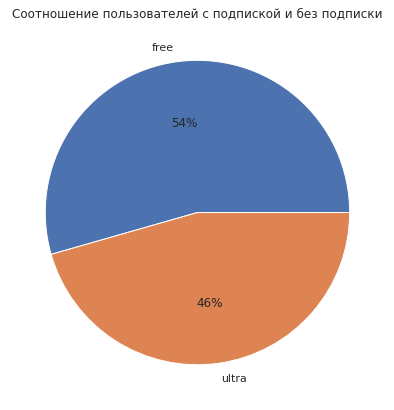

In [29]:
# Комментарий 
import matplotlib.pyplot as plt
temp = users.copy()
temp['subscription_type'].value_counts().plot(
    kind= 'pie',
    title= 'Соотношение пользователей с подпиской и без подписки',
    autopct = "%.0f%%",
    ylabel= ""
)
plt.show()

#### Возраст пользователей

In [30]:
#  создание таблицы соотношения пользователей по возрасту 
users_age = users.groupby('age')['user_id'].count().reset_index()
users_age['percent']=round(users_age['user_id']/len(users)*100,1)
users_age.columns = ['age','count','percent']
users_age=users_age.sort_values(by='age')
users_age

,age,count,percent
0,12,4,0.3
1,13,8,0.5
2,14,9,0.6
3,15,13,0.8
4,16,19,1.2
5,17,26,1.7
6,18,46,3.0
7,19,47,3.1
8,20,71,4.6
9,21,93,6.1


In [31]:
#  вывод статистической информации по столбцу возраст
users['age'].describe().round(2)

count    1534.00
mean       24.90
std         4.57
min        12.00
25%        22.00
50%        25.00
75%        28.00
max        43.00
Name: age, dtype: float64

**Среднее и медианные значения отличаются на 0.1 ,  можно сделать вывод , что явных смещений по возрасту нет.**

**Построим столбчатый график распределения возраста.**

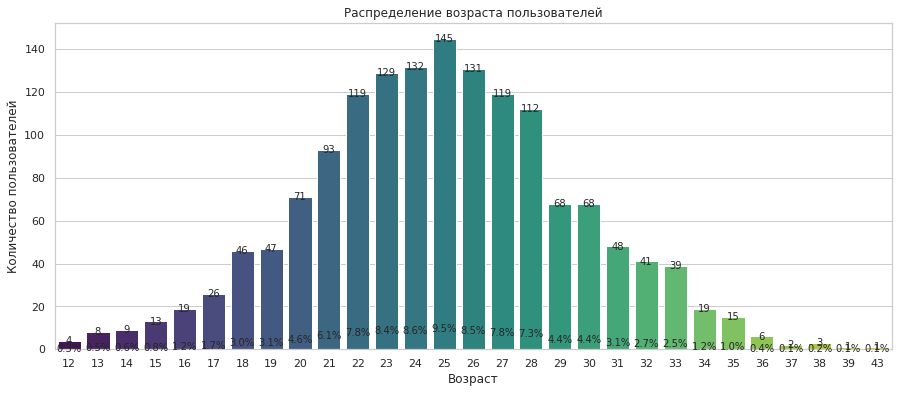

In [32]:
# Настройка графика
plt.figure(figsize=(15,6))
sns.barplot(x=users_age['age'], y=users_age['count'], palette="viridis")


# Добавляем подписи на график
for index, value in enumerate(users_age['count']):
    plt.text(index, value, str(value),ha='center', va='center',fontsize=10)  

# Добавляем подписи на график
for index, value in enumerate(users_age['percent']):
    plt.text(index, value, str(value)+'%',ha='center', va='center',fontsize=10)

# Добавляем подписи на график    
plt.title('Распределение возраcта пользователей')
plt.xlabel('Возраст')
plt.ylabel('Количество пользователей')
plt.show()

**Рассмотрим частотное распределение возраста методом построения гистограммы.**

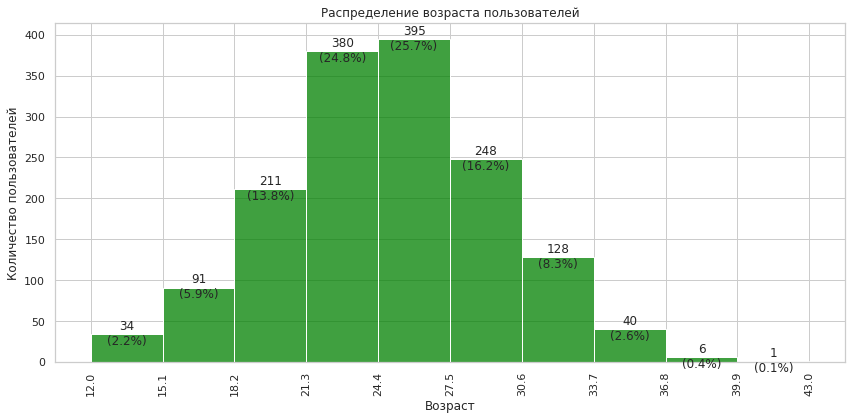

In [33]:
# Создание гистограммы
plt.figure(figsize=(12,6))
ax = sns.histplot(users['age'],bins=10, color= 'green')

# Общее количетсво пользователей 
total_users = len(users)

# Добавляем подписи данных
for p in ax.patches:
    height = p.get_height() #  подсчет кол-ва пользователей
    percentage = (height/total_users)*100  # процент пользователей
    ax.annotate(f'{int(height)}\n({percentage:.1f}%)', # подписи: количество и процент 
               (p.get_x() + p.get_width()/2.,height), # позиция текста 
                ha='center', va='center', # выравнивание текста
                xytext=(0,0.5), # смещение тектса
                textcoords='offset points') # система координат для смещения
    
# настройка промежуточных подписей оси х

bin_edges = ax.patches[0].get_x() # левая граница первого столбца
bin_width = ax.patches[0].get_width()# ширина столбца
bin_edges = [patch.get_x() for patch in ax.patches]+[ax.patches[-1].get_x()+ bin_width] # все границы
ax.set_xticks(bin_edges) 
ax.set_xticklabels([f'{edge:.1f}' for edge in bin_edges],rotation=90)

# подписи графика
plt.title('Распределение возраста пользователей')
plt.xlabel('Возраст')
plt.ylabel('Количество пользователей')
plt.tight_layout()
plt.show()

**Визуализация распределения возраста по количеству соотвествует нормальноум распределению.**

**Медианный возраст пользователей аренды самокатов 25 лет.**

**Ядро пользователей с возрастом от 22 до 28 лет, что соотвествует диапазону 1-3 квартилей. Таких пользователей около 50%.**

**Самому младшему пользователю самокатов 12 лет, самому старшему 43 года.**


#### Расстояние, которое пользователь в среднем преодолевает за одну поездку

In [34]:
#  вывод статистической информации по столбцу дистанция
rides['distance'].describe().round(2)

count    18068.00
mean      3070.66
std       1116.83
min          0.86
25%       2543.23
50%       3133.61
75%       3776.22
max       7211.01
Name: distance, dtype: float64

**Среднее значение от медианы немного отличаются, возможно, в данных есть аномалии.**

**Построим частотное распределение расстояния одной поездки.**

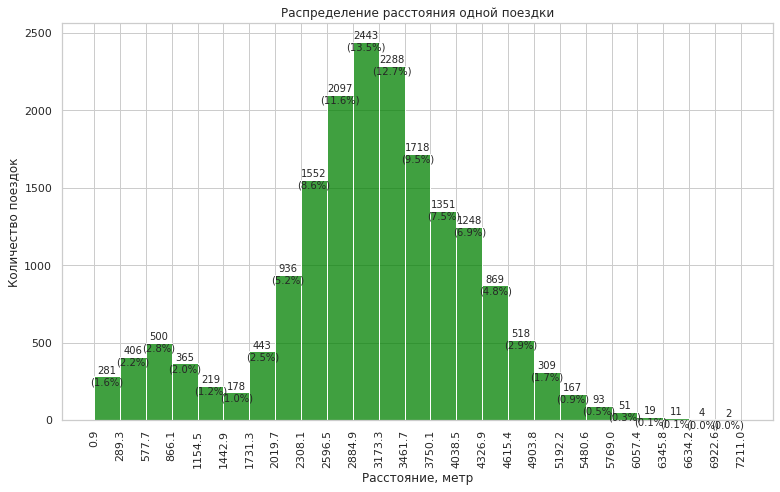

In [35]:
# Создание гистограммы

ax = sns.histplot(rides['distance'],bins=25, color= 'green')

# Общее количетсво пользователей 
total_users = len(rides)

# Добавляем подписи данных
for p in ax.patches:
    height = p.get_height() #  подсчет кол-ва пользователей
    percentage = (height/total_users)*100  # процент пользователей
    ax.annotate(f'{int(height)}\n({percentage:.1f}%)', # подписи: количество и процент 
               (p.get_x() + p.get_width()/2.,height), # позиция текста 
                ha='center', va='center', # выравнивание текста
                xytext=(0,0.5), # смещение тектса
                textcoords='offset points',# система координат для смещения
                fontsize= 10 ) 
    
# настройка промежуточных подписей оси х

bin_edges = ax.patches[0].get_x() # левая граница первого столбца
bin_width = ax.patches[0].get_width()# ширина столбца
bin_edges = [patch.get_x() for patch in ax.patches]+[ax.patches[-1].get_x()+ bin_width] # все границы
ax.set_xticks(bin_edges) 
ax.set_xticklabels([f'{edge:.1f}' for edge in bin_edges],rotation=90)


# подписи графика
plt.title('Распределение расстояния одной поездки')
plt.xlabel('Расстояние, метр')
plt.ylabel('Количество поездок')
plt.tight_layout()
plt.show()

**Медианное расстояние одной поездки равно 3133.61 метрам.**

**В соотвествии с графиком можно отметить, что в диапазоне от 1,4 до 7,2 км распределение расстояний одной поездки соотвествует нормальному. Чаще всего за одну поездку пользователи проезжают от 2,5 до 3,7 метров.**

**Также важно отметить всплеск поездок в промежутке от 0 до 1,4 км, с пиком 577-866 метров. Это совсем небольшое расстояние. Возможно это связано с новыми пользователиями, которые совершают короткие поездки, чтобы оценить электросамокаты на предмет нравится/не нравится, в том числе понять, как работает сервис и примерный бюджет поездки.**

**Также короткие поездки могут быть связаны с обнаруженными в поездке неисправностями электросамоката или разряженная батарея самоката.**

#### Продолжительность поездок

In [36]:
#  вывод статистической информации по столбцу длительность поездки
rides['duration'].describe().round(2)

count    18068.00
mean        18.30
std          6.09
min          1.00
25%         14.00
50%         18.00
75%         22.00
max         41.00
Name: duration, dtype: float64

**Медианное и среднее значения практически одинаковые, можно сделать вывод , что явных смещений по длительности поездки нет.**

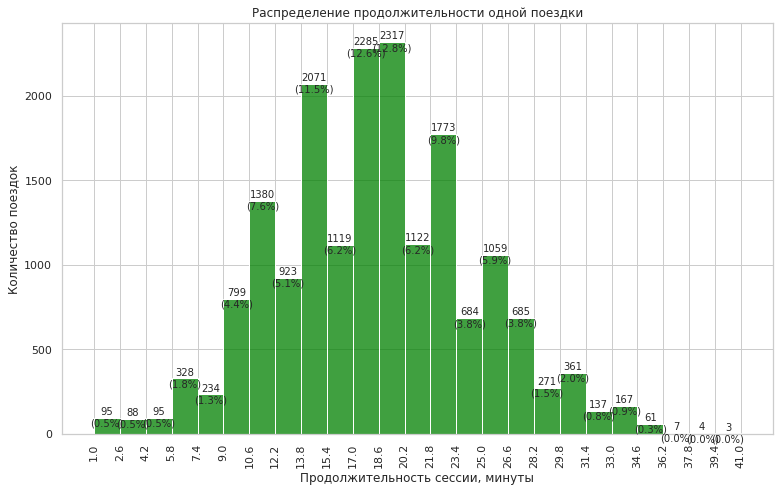

In [37]:
# Создание гистограммы

ax = sns.histplot(rides['duration'],bins=25, color= 'green')

# Общее количетсво пользователей 
total_users = len(rides)

# Добавляем подписи данных
for p in ax.patches:
    height = p.get_height() #  подсчет кол-ва пользователей
    percentage = (height/total_users)*100  # процент пользователей
    ax.annotate(f'{int(height)}\n({percentage:.1f}%)', # подписи: количество и процент 
               (p.get_x() + p.get_width()/2.,height), # позиция текста 
                ha='center', va='center', # выравнивание текста
                xytext=(0,0.5), # смещение тектса
                textcoords='offset points',# система координат для смещения
                fontsize= 10 ) 
    
# настройка промежуточных подписей оси х

bin_edges = ax.patches[0].get_x() # левая граница первого столбца
bin_width = ax.patches[0].get_width()# ширина столбца
bin_edges = [patch.get_x() for patch in ax.patches]+[ax.patches[-1].get_x()+ bin_width] # все границы
ax.set_xticks(bin_edges) 
ax.set_xticklabels([f'{edge:.1f}' for edge in bin_edges],rotation=90)


# подписи графика
plt.title('Распределение продолжительности одной поездки')
plt.xlabel('Продолжительность сессии, минуты')
plt.ylabel('Количество поездок')
plt.tight_layout()
plt.show()

**В соответсвии с гистограммой распределение длительности одной поездки соответсвует нормальному.**

**Медианное значение длительности одной поездки 17.68 минут.**

**Чаще всего пользователи катаются от 13,60 до 21,72 минут, в соотвествии с диапазоном 1-3 квартилей.**



Краткое резюме по исследовательскому анализу:


- Всего зарегистрировано 1534 уникальных пользователя. Доля  пользователей без подписки free 54.43 % превышает на 8.86 % долю пользователей с подпиской ultra 45.57 %
    
    
- Распределения возраста по количеству соотвествует нормальноум распределению. Типичный пользователь - это пользователь возрастом от 22 до 28 лет. Медианный возраст 25 лет. Самому старшему 43 года, а самому младшему 12 лет, что является нарушением существующих норм, так как по закону прокат разрешен с 18 лет, в некоторых компаниях с 14 лет с письменного согласия родителей.
    

 - Исследуемый сервис аренды самокатов присутствует в 8 городах. 4 города из них - это крупные города миллионеры, промышленные, культурные и научные центры: Екатеринбург, Тюмень, Омск и Москва. А также 4 города южного федерального округа, одни из самых важных курортно-туристических направлений: Пятигорск, Ростов-на Дону, Краснодар, Сочи. В тройку лидеров входят города: Пятигорск 14,28% , Екатеринбург 13,3%, Ростов-на Дону 12,91%. На последнем месте Москва с долей пользователей 10,95%. 
    
    
- Чаще всего за одну поездку пользователи проезжают от 2,5 до 3,7 км. Медианное расстояние одной поездки равно 3133.61 метрам. В данных расстояний одной поездки наблюдаются аномалии в зоне коротких поездок, с пиком 577-866 метров. Это может быть связано с неисправностями самоката или низкий заряд батареи или новые пользователи тестируют сервис. Аномалии являются важной частью для исследования поведения пользователей, поэтому данные сохраняем как есть.
    
   
- Распределение длительности одной поездки соответсвует нормальному, без явных аномалий. Медианное значение длительности одной поездки 17.68 минут. Чаще всего пользователи катаются от 13,60 до 21,72 минут. Можно отметить небольшую аномилию с поездками длительностью менее 1 минуты. Это могут оплаты без подписки фиксированной суммы только за старт поездки. Поездки менее минуты также не удаляем, так как в дальнейшем производится расчет выручки, которая определяет финансовый результат Сервиса аранды самокатов


### Объединение данных в один датафрейм и сравнение поездок пользователей обеих категорий

In [38]:
# создание нового датафрейм, объдинение таблиц поездок с данными о пользователях
data = rides.merge(users, on = 'user_id', how='left')
# добавление в новый датафрейм информации о стоимости тарифов
data = data.merge (subscriptions, on = 'subscription_type')
data.head(10)

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,4409.92,26.0,2021-01-01,1,Кира,22,Тюмень,ultra,6,0,199
1,1,2617.59,16.0,2021-01-18,1,Кира,22,Тюмень,ultra,6,0,199
2,1,754.16,7.0,2021-04-20,4,Кира,22,Тюмень,ultra,6,0,199
3,1,2694.78,19.0,2021-08-11,8,Кира,22,Тюмень,ultra,6,0,199
4,1,4028.69,27.0,2021-08-28,8,Кира,22,Тюмень,ultra,6,0,199
5,1,2770.89,17.0,2021-10-09,10,Кира,22,Тюмень,ultra,6,0,199
6,1,3039.02,15.0,2021-10-19,10,Кира,22,Тюмень,ultra,6,0,199
7,1,2842.12,24.0,2021-11-06,11,Кира,22,Тюмень,ultra,6,0,199
8,1,3412.69,16.0,2021-11-14,11,Кира,22,Тюмень,ultra,6,0,199
9,1,748.69,16.0,2021-11-22,11,Кира,22,Тюмень,ultra,6,0,199


In [39]:
# проверка размерности и наличие пропусков после объединения 
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18068 entries, 0 to 18067
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            18068 non-null  int64         
 1   distance           18068 non-null  float64       
 2   duration           18068 non-null  float64       
 3   date               18068 non-null  datetime64[ns]
 4   month              18068 non-null  int64         
 5   name               18068 non-null  object        
 6   age                18068 non-null  int64         
 7   city               18068 non-null  object        
 8   subscription_type  18068 non-null  object        
 9   minute_price       18068 non-null  int64         
 10  start_ride_price   18068 non-null  int64         
 11  subscription_fee   18068 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 1.8+ MB


Количество записей соответствует исходному датасету с поездками, пропусков не обнаружено, датасеты объединены коректно.

#### Создание датафрейм только с данными о пользователях с подпиской

In [40]:
# создание датафрейм только с данными о пользователях с подпиской
data_ultra = data.query('subscription_type=="ultra"').copy()
data_ultra.head()

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,4409.92,26.0,2021-01-01,1,Кира,22,Тюмень,ultra,6,0,199
1,1,2617.59,16.0,2021-01-18,1,Кира,22,Тюмень,ultra,6,0,199
2,1,754.16,7.0,2021-04-20,4,Кира,22,Тюмень,ultra,6,0,199
3,1,2694.78,19.0,2021-08-11,8,Кира,22,Тюмень,ultra,6,0,199
4,1,4028.69,27.0,2021-08-28,8,Кира,22,Тюмень,ultra,6,0,199


#### Создание датафрейм только с данными о пользователях без подписки

In [41]:
data_free = data.query('subscription_type=="free"').copy().reset_index(drop=True)
data_free.head()

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,700,2515.69,15.0,2021-01-02,1,Айдар,22,Омск,free,8,50,0
1,700,846.93,17.0,2021-02-01,2,Айдар,22,Омск,free,8,50,0
2,700,4004.43,21.0,2021-02-04,2,Айдар,22,Омск,free,8,50,0
3,700,1205.91,10.0,2021-02-10,2,Айдар,22,Омск,free,8,50,0
4,700,3047.38,18.0,2021-02-14,2,Айдар,22,Омск,free,8,50,0


#### Визуализация информации о расстоянии и времени поездок для пользователей обеих категорий.

In [42]:
#  вывод статистической информации длительности поездки без подписки
data_free['distance'].describe().round(2)

count    11568.00
mean      3045.50
std       1246.17
min          0.86
25%       2366.56
50%       3114.65
75%       3905.70
max       7211.01
Name: distance, dtype: float64

In [43]:
#  вывод статистической информации длительности поездки с подпиской
data_ultra['distance'].describe().round(2)

count    6500.00
mean     3115.45
std       836.90
min       244.21
25%      2785.45
50%      3148.64
75%      3560.58
max      5699.77
Name: distance, dtype: float64

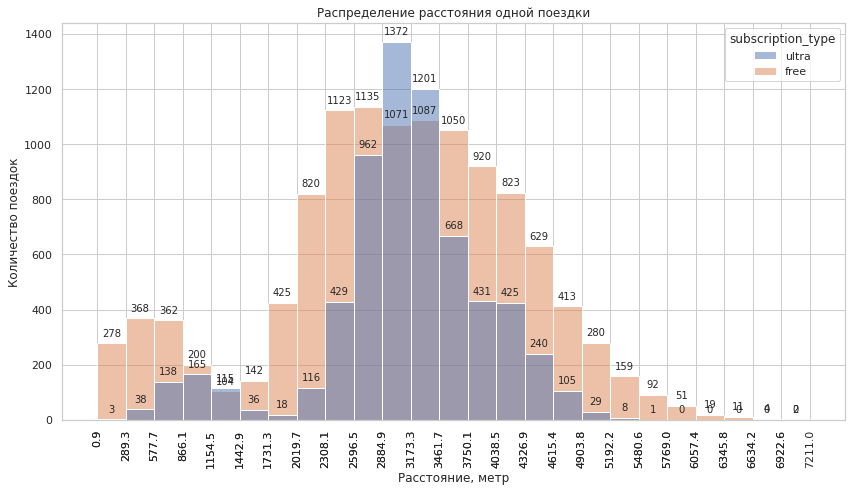

In [44]:
# Создание гистограммы
plt.figure(figsize=(12,7))
ax = sns.histplot(data = data, x ='distance',hue ='subscription_type', bins=25)

# Добавляем подписи данных
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', # подписи: количество 
               (p.get_x() + p.get_width()/2.,p.get_height()), # позиция текста 
                ha='center', va='bottom', # выравнивание текста
                xytext=(0,5), # смещение тектса
                textcoords='offset points',# система координат для смещения
                fontsize= 10 ) 
    
# настройка промежуточных подписей оси х

bin_edges = ax.patches[0].get_x() # левая граница первого столбца
bin_width = ax.patches[0].get_width()# ширина столбца
bin_edges = [patch.get_x() for patch in ax.patches]+[ax.patches[-1].get_x()+ bin_width] # все границы
ax.set_xticks(bin_edges) 
ax.set_xticklabels([f'{edge:.1f}' for edge in bin_edges],rotation=90)


# подписи графика
plt.title('Распределение расстояния одной поездки')
plt.xlabel('Расстояние, метр')
plt.ylabel('Количество поездок')
plt.tight_layout()
plt.show()

**Рисунок распределения продолжительности одной поездки с подпиской и без подписки схож, с нормальным распределением от 1,45 км, и наличием небольшого всплеска на коротких дистанциях от о до 1,45 км.**

**Пользователи без подписки чаще всего проезжают от 2366 до 3905 метров.
Медианное расстояние поездки без подписки 3114 метра.**

**Пользователи с подпиской чаще всего проезжают от  2785 до 3560 метров.
Медианное расстояние поездки с подпиской 3148 метра.**

**У пользователей с подпиской более узкий диапазон расстояния  и ближе сосредоточен к медиане, о чем свидетельсвует меньшее отклонение 836, чем  отклонение 1246 поездок free.**

**Всплеск на коротких дистанциях наблюдается в обеих группах, вряд ли пользователь с подпиской тестирует сервис, так как уже принял решение пользоваться услугой, возможно всплески связаны именно с обнаруженными неисправностями или разряженными самокатами.**

In [45]:
#  вывод статистической информации продолжительности поездки без подписки
data_free['duration'].describe().round(2)

count    11568.00
mean        17.89
std          6.33
min          1.00
25%         13.00
50%         18.00
75%         22.00
max         35.00
Name: duration, dtype: float64

In [46]:
#  вывод статистической информации продолжительности поездки с подпиской
data_ultra['duration'].describe().round(2)

count    6500.00
mean       19.04
std         5.58
min         4.00
25%        15.00
50%        19.00
75%        22.00
max        41.00
Name: duration, dtype: float64

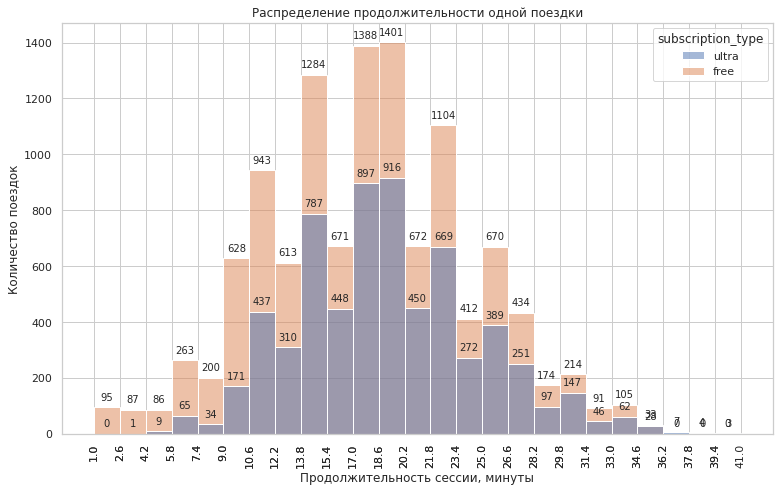

In [47]:
# Создание гистограммы

ax = sns.histplot(data = data, x ='duration',hue ='subscription_type', bins=25)

# Добавляем подписи данных
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', # подписи: количество 
               (p.get_x() + p.get_width()/2.,p.get_height()), # позиция текста 
                ha='center', va='bottom', # выравнивание текста
                xytext=(0,5), # смещение тектса
                textcoords='offset points',# система координат для смещения
                fontsize= 10 ) 
    
# настройка промежуточных подписей оси х

bin_edges = ax.patches[0].get_x() # левая граница первого столбца
bin_width = ax.patches[0].get_width()# ширина столбца
bin_edges = [patch.get_x() for patch in ax.patches]+[ax.patches[-1].get_x()+ bin_width] # все границы
ax.set_xticks(bin_edges) 
ax.set_xticklabels([f'{edge:.1f}' for edge in bin_edges],rotation=90)


# подписи графика
plt.title('Распределение продолжительности одной поездки')
plt.xlabel('Продолжительность сессии, минуты')
plt.ylabel('Количество поездок')
plt.tight_layout()
plt.show()

**Распределение продолжительности поездки с подпиской и без также схожи.**

**Длительность поездки без подписки чаще всего от 12.96 до 21.59 минут.
Медианное время поездки без подписки 17.33 минуты.**

**Длительность поездки с подпиской чаще всего от  14.52 до 21.88 минут.
Медианное время поездки с подпиской 18.18 минут.**

**Типичная поездка с подпиской длинее на 45 секунд.**

### Проверка гипотез. Сравнение поездок с подпиской и без.

#### Подсчёт выручки

**Для проверки гипотез подготовим данные, узнаем какую выручку приносит каждый пользователь помесячно.**

**Для этого создадим датафрейм с агрегированными данными о поездках: суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц.**

In [48]:
# создаем датафрейм с агрегированными данными о поездках
data_statistical = (
    data.groupby(['user_id','subscription_type','month','minute_price',
                  'start_ride_price','subscription_fee'])
    .agg({'distance': 'sum','duration':['sum','count']}).reset_index()
)
data_statistical.columns = ['user_id','subscription_type','month','minute_price',
                            'start_ride_price','subscription_fee','distance_total',
                            'duration_total','ride_count']
data_statistical.head(10)

,user_id,subscription_type,month,minute_price,start_ride_price,subscription_fee,distance_total,duration_total,ride_count
0,1,ultra,1,6,0,199,7027.51,42.0,2
1,1,ultra,4,6,0,199,754.16,7.0,1
2,1,ultra,8,6,0,199,6723.47,46.0,2
3,1,ultra,10,6,0,199,5809.91,32.0,2
4,1,ultra,11,6,0,199,7003.50,56.0,3
5,1,ultra,12,6,0,199,6751.63,28.0,2
6,2,ultra,3,6,0,199,10187.73,63.0,3
7,2,ultra,4,6,0,199,6164.39,40.0,2
8,2,ultra,6,6,0,199,3255.34,14.0,1
9,2,ultra,7,6,0,199,6780.73,48.0,2


In [49]:
# проверка на корректность и пропуски созданной сводной таблицы
data_statistical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11331 entries, 0 to 11330
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            11331 non-null  int64  
 1   subscription_type  11331 non-null  object 
 2   month              11331 non-null  int64  
 3   minute_price       11331 non-null  int64  
 4   start_ride_price   11331 non-null  int64  
 5   subscription_fee   11331 non-null  int64  
 6   distance_total     11331 non-null  float64
 7   duration_total     11331 non-null  float64
 8   ride_count         11331 non-null  int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 796.8+ KB


Пропуски отсутствуют, сводная таблица построена корректно. 

In [50]:
# подсчет выручки по каждому пользователю по месяцам
data_statistical['revenue'] = (
    data_statistical['ride_count']*data_statistical['start_ride_price']
    +data_statistical['minute_price']*data_statistical['duration_total']
    +data_statistical['subscription_fee'])
data_statistical.head(3)

,user_id,subscription_type,month,minute_price,start_ride_price,subscription_fee,distance_total,duration_total,ride_count,revenue
0,1,ultra,1,6,0,199,7027.51,42.0,2,451.0
1,1,ultra,4,6,0,199,754.16,7.0,1,241.0
2,1,ultra,8,6,0,199,6723.47,46.0,2,475.0


In [51]:
print('Общая сумма выручки за 2021 год составила', data_statistical['revenue'].sum())
print('Cумма выручки тарифа free составила', data_statistical.query('subscription_type=="free"')['revenue'].sum())
print('Cумма выручки тарифа ultra составила', data_statistical.query('subscription_type=="ultra"')['revenue'].sum())

Общая сумма выручки за 2021 год составила 3878641.0
Cумма выручки тарифа free составила 2234104.0
Cумма выручки тарифа ultra составила 1644537.0


####  Проверка гипотезы. Пользователи с подпиской тратят больше времени на поездки

**Если гипотеза верна, то пользователи с подпиской могут быть «выгоднее» для компании.**

**Сформируем гипотезы для проведения теста:**

**Н0:** Средняя продолжительность поездок с подпиской  и без равна

**Н1:** Средняя продолжительность поездок с подпиской  больше продолжительности поездок без подписок

Для проверки гипотезы, используем отдельные датафреймы по поездкам free и ultra.**

**Установим уровень статистической значимости 5%.**

In [52]:
alpha = 0.05 # уровень статистической значимости
# если p-value окажется меньше него, отвергнем гипотезу

# проводим ttest для двух выборок, в качестве альтернативной используем одностороннюю гипотезу «больше»
results = st.ttest_ind(data_ultra['duration'], data_free['duration'], equal_var=True, alternative='greater')

print(f'p-value: {results.pvalue}')

# проверяем p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

p-value: 2.4959453720736625e-34
Отвергаем нулевую гипотезу


In [53]:
# выведем средние значения поездок с подпсокй и без
print('Средняя продолжительность поездки в подпиской:', round(data_ultra['duration'].mean(),2))
print('Средняя продолжительность поездки без подписки:', round(data_free['duration'].mean(),2))

Средняя продолжительность поездки в подпиской: 19.04
Средняя продолжительность поездки без подписки: 17.89


**ВЫВОД:**

**Нулевая гипотеза о равной продолжительности поездок с подпиской и без отвергнута.**

**Есть основания предполагать, что средняя продолжительность поездок с подпиской больше продолжительности поездок без подписок. Разница средних значений времени поездок с подпиской и без больше 1 минуты.**



#### Проверка гипотезы. Среднее расстояние поездки с подпиской не превышает точки износа самоката в 3130 м.

**Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката.**

**Проверим можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров?**

**Сформируем гипотезы для проведения теста:**

**Н0:** Среднее расстояние поездки с подпиской равно оптимальному расстоянию 3130 метров 

**Н1:** Среднее расстояние поездки с подпиской  превышает точку износа самоката 3130 метров 

Для проверки гипотезы, используем отдельные датафреймы по поездкам free и ultra.**

**Установим уровень статистической значимости 5%.**

In [54]:
distance = 3130 # дистанция точки износа для сравнения

alpha = 0.05 # уровень статистической значимости
# если p-value окажется меньше него, отвергнем гипотезу

# проводим ttest методом st.ttest_1samp, , в качестве альтернативной используем одностороннюю гипотезу «больше»
results = st.ttest_1samp(
    data_ultra['distance'], 
    distance,
    alternative='greater')

print('p-значение:', results.pvalue)

if (results.pvalue < alpha):
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу') 

p-значение: 0.9195362605842414
Не отвергаем нулевую гипотезу


**ВЫВОД:**

**По итогам проведения теста нулевую гипотезу не получилось отвергнуть. Значит, есть основания предполагать, что  среднее расстояние поездки с подпиской не превышает точку износа самоката 3130 метров.**


#### Проверка гипотезы. Помесячная выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки.

**Сформируем гипотезы для проведения теста:**

**Н0:** Помесячная выручка от пользователей с подпиской и без равна

**Н1:** Помесячная выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки

Для проверки гипотезы, используем отдельные датафреймы по поездкам free и ultra.**

**Установим уровень статистической значимости 5%.**

In [55]:
alpha = 0.05 # уровень статистической значимости
# если p-value окажется меньше него, отвергнем гипотезу

# проводим ttest для двух выборок, в качестве альтернативной используем одностороннюю гипотезу «больше»
results = st.ttest_ind(data_statistical.query('subscription_type=="ultra"')['revenue'],
                       data_statistical.query('subscription_type=="free"')['revenue'],
                       equal_var=True, alternative='greater')

print(f'p-value: {results.pvalue}')

# проверяем p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

p-value: 1.8850394384715216e-31
Отвергаем нулевую гипотезу


**ВЫВОД:**

**Нулевая гипотеза о равной помеесячной вырочку с подпиской и без отвергнута.**

**По результатам теста, есть основания предполагать, что помесячная выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки.**

#### Ответ на вопрос

Представьте такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест вам понадобился бы для проверки этой гипотезы?

**Если в выборках до обновления и после обновления представлены только одни и те же постоянные пользователи, выборки в этом случае будут зависимыми, иначе — парными. Это означает, что одни и те же пользователи  измеряются дважды на предмет обращений в тех поддержку до  и после обновления. В таком случае , чтобы проверить гипотезу о равенстве среднего генеральной совокупности для зависимых выборок подходит метод scipy.stats.ttest_rel().**

Это левостороняя гипотеза, которую можно сформулировать следующим образом::

Н0: Кол-во обращений одних и тех же пользователей в тех поддержку до обновления и после обновения равны

Н1: Кол-во обращений одних и тех же пользователей в тех поддержку после обновения стало меньше

Для проверки гипотезы, используем отдельные датафреймы по поездкам free и ultra.**

**Если нет уверенности, что выборки состоят из одних и тех же пользователей, так как , например, в после обновления сервиса появились новые пользователи и они могли попасть в выборку, тогда подходит метод scipy.stats.ttest_ind().**

### Расчеты для проведения маркетинговых мероприятий

#### Акция с раздачей промокодов

**Описание задачи:**

Отделу маркетинга сервича самокатов нужно провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум 100 существующих клиентов должны продлить эту подписку. То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж. 

Эта акция уже проводилась ранее и по итогу выяснилось, что после бесплатного пробного периода подписку продлевают 
10 % пользователей. 

Необходимо выяснить, какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно 5 %. 

Необходимо раздать минимум 1161 промокодов, чтобы получить 100 подписок и вероятностью не выполнить план до 5%


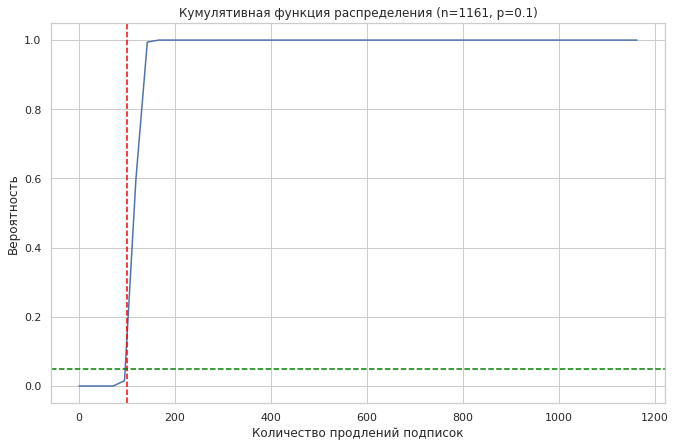

In [56]:
# параметры

p = 0.1 # вероятность продления подписки
p_minus = 0.05 # плановая вероятность невыполнения плана
min_subscription = 100 # минимальное количество подписок, которое нужно получить

# Функция для поиска минимального количества промокодов для выполнения плана
def promokod (p, p_minus, min_subscription ):
    n = min_subscription # начинаем с минимального количества продлений
    while True:
        select = binom.cdf(min_subscription-1, n, p)
        if  select <= p_minus:
            return n
        n +=1
n =  promokod(p, p_minus, min_subscription)  
print('Необходимо раздать минимум', n,
      'промокодов, чтобы получить 100 подписок и вероятностью не выполнить план до 5%')

# Параметры для построения графика

x = np.linspace(0,n+1) # массив со всем количеством продлений подписок (n)
y = binom.cdf(x,n,p) # передаём массив в функцию

# Построение графика 
plt.plot (x,y)
plt.axvline(x=100,color = 'red',linestyle = '--')
plt.axhline(y=0.05,color = 'green',linestyle = '--')
plt.xlabel('Количество продлений подписок')
plt.ylabel('Вероятность')
plt.title (f'Кумулятивная функция распределения (n={n}, p={p})')
plt.show;



#### Рассылка push-уведомлений

**Описание задачи:**

Отдел маркетинга планирует разослать клиентам 1 млн push-уведомлений в мобильном приложении. Известно, что уведомления открывают около 40 % получивших клиентов. 

Необходимо оценить вероятность того, что уведомление откроют не более 399,5 тыс. пользователей.

Вероятность открытия не более 399500 сообщений при рассылке в 1 млн уведомлений равна: 15.37 процентов


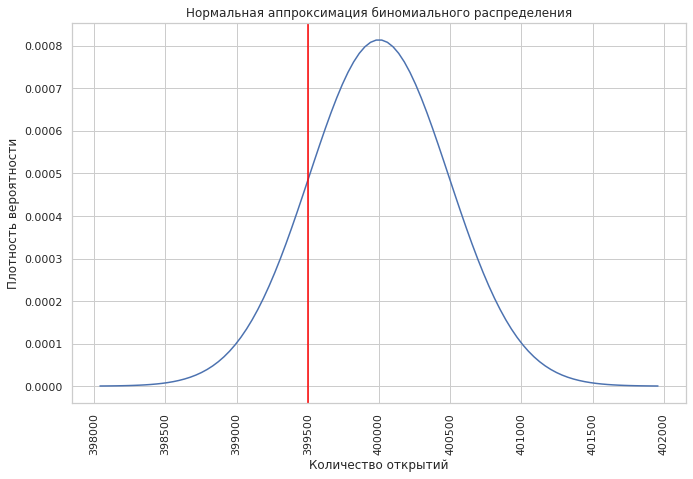

In [57]:
# параметры 

n = 1000000 # количество уведомлений
p = 0.4     # вероятность открытия письма
k = 399500  # максимальное количество открытий

# среднее и стандартное отклонение
mu = n * p
sigma = sqrt(n * p * (1 - p))

# задаём нормальное распределение
distr = st.norm(mu, sigma) 

# считаем вероятность p(X<=399500)
result = distr.cdf(k)
print('Вероятность открытия не более 399500 сообщений при рассылке в 1 млн уведомлений равна:',
      round(result*100,2), 'процентов')

# Строим график нормального распределения

x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 100) # дипазон значений  в пределах ± 4 ст.отклонений от мат.ожидания
y = norm.pdf(x,mu,sigma)# плотность вероятности

# строим график
plt.plot(x,y)
plt.xticks(rotation=90)
plt.axvline(x=k, color='red')
plt.xlabel('Количество открытий')
plt.ylabel('Плотность вероятности')
plt.title ('Нормальная аппроксимация биномиального распределения')
plt.show()

### ОБЩИЕ ВЫВОДЫ

**В процессе проведения анализа сервиса электросамокатов GoFast были выполнены следующие шаги и сделаны выводы:**

**1. Загрузка данных:**

**1.1 В таблице с данными о пользователях:**

- всего 1565 записей, пропусков не наблюдается, типы данных верные, названия столбцов стилистически верные.

**1.2 В таблице с данными о поездках:**

- всего 18068 записей, пропусков не наблюдается, названия столбцов стилистически верные.

- колонка date некорректного типа данных, необходимо исправить.

- в численных колонках distance и duration 6 знаков после запятой, следует округлить данные для дальнейшей обработки. Данные в колонке distance сократить до 2-ух знаков. Данные в колонке duration необходимо округлить до следующего целого числа.

**1.3 В таблице с данными о тарифах:**

- всего 2 записи, пропусков не наблюдается, типы данных верные, названия столбцов стилистически верные.

**2. Предобработка данных**

**2.1 В таблице с данными о пользователях:**

- обнаружены и удалены 31 явных дубликата

**2.2 В таблице с данными о поездках:**

- колонка date преобразована к коректному типу данных date. 

- колонку distance округлили до 2-ух знаков после запятой
    
- колонку duration округлили до следующего целого числа
    
- добавили новую колонку с номером месяца 

**2.3 В таблице с данными о тарифах:**

- каких либо преобразований не проводилось

**3. Исследовательский анализ данных. Общие наблюдения о пользователях и поездках сервиса самокатов**

- На период 2021 года зарегистрировано 1534 уникальных пользователя.

- Доля  пользователей без подписки free 54.43% - 835 чел. , с подпиской ultra 45.57% - 699 чел. Пользователей без подписки на 8.86 % больше.


- Медианный возраст пользователей аренды самокатов 25 лет. Ядро пользователей с возрастом от 22 до 28 лет. Таких пользователей около 50%. Самому старшему 43 года. Самому младшему пользователю самокатов 12 лет, стоит обратить внимание менеджеров сервиса проката о наличии нарушения существующих норм, так как по закону прокат разрешен с 18 лет, минимальный возраст может быть с 14 лет с письменного согласия родителей.


- Исследуемый сервис аренды самокатов присутствует в 8 городах. 4 города из них - это крупные города миллионеры, промышленные, культурные и научные центры: Екатеринбург, Тюмень, Омск и Москва. А также 4 города южного федерального округа, одни из самых важных курортно-туристических направлений: Пятигорск, Ростов-на Дону, Краснодар, Сочи. В тройку лидеров входят города: Пятигорск 14,28% , Екатеринбург 13,3%, Ростов-на Дону 12,91%. На последнем месте Москва с долей пользователей 10,95%. 


- Медианное расстояние одной поездки равно 3133.61 метрам. Чаще всего за одну поездку пользователи проезжают от 2,5 до 3,7 км. Максимальное расстояние поездки составляет 7,2 км. 


- Также важно отметить небольшой всплеск коротких поездок в промежутке от 0 до 1,4 км, с пиком 577-866 метров. Такие короткие поездки могут быть связаны с обнаруженными в поездке неисправностями электросамоката или разряженная батарея самоката. Плюс, новые пользователи моут тестировать электросамокаты на предмет нравится/не нравится, в том числе понять, как работает сервис и примерный бюджет поездки.


- Распределение длительности одной поездки соответсвует нормальному. Медианное значение длительности одной поездки 17.68 минут. Чаще всего пользователи катаются от 13,60 до 21,72 минут. Следует отметить небольшую аномилию с поездками длительностью менее 1 минуты. Это может быть с вязано с укзанными причинами коротких поездок, также это могут быть оплаты без подписки фиксированной суммы только за старт поездки. Для  дальнейшей диагностики средств контроля времени поездки следует обратить внимание на данный факт.

**4. Сравнение данных о поездках с подпиской и без:**

- Распределения продолжительности одной поездки с подпиской и без подписки очень похожи, с наличием небольшого всплеска на коротких дистанциях от о до 1,45 км. Как раннее было описано, скорее всего это связано, либо с неисправностями самоката, которые были обнаружены в первые минуты поездки, либо новые пользователи тестируют сервис.


- Пользователи без подписки чаще всего проезжают от 2366 до 3905 метров. Медианное расстояние поездки без подписки 3114 метра. Пользователи с подпиской чаще всего проезжают от 2785 до 3560 метров. Медианное расстояние поездки с подпиской 3148 метра. Отклонение в данных о поездках с подпиской меньше, чем в поездках без подписки, а также медиана расстояния одной поездки с подпиской выше, можно предположить, что у пользователей с подпиской длинее дистанции.


- Распределения продолжительности поездки с подпиской и без также такж очень похожи. Длительность поездки без подписки чаще всего от 12.96 до 21.59 минут. Медианное время поездки без подписки 17.33 минуты. Длительность поездки с подпиской чаще всего от 14.52 до 21.88 минут. Медианное время поездки с подпиской 18.18 минут. Типичная поездка с подпиской длинее на 45 секунд. Также можно предположить, что пользователи с подпиской катаются дольше по времени.


- Общая сумма выручки за 2021 год составила 3 878 641 руб.
Cумма выручки тарифа free составила 2 234 104 руб.
Cумма выручки тарифа ultra составила 1 644 537 руб.

**5. Проверка гипотез.**

**5.1  Итоги проверки гипотезы. Пользователи с подпиской тратят больше времени на поездки.**

При статистической значимости 5% показатель pvalue оказался меньше , соотвественно есть основания предполагать, что средняя продолжительность поездок с подпиской больше продолжительности поездок без подписок. Пользователи с подпиской могут быть «выгоднее» для компании.

Средняя продолжительность поездки в подпиской: 19.04
Средняя продолжительность поездки без подписки: 17.89
Разница средних значений времени поездок с подпиской и без больше 1 минуты. 

**5.2 Итоги проверки гипотезы. Среднее расстояние поездки с подпиской не превышает точки износа самоката в 3130 м.**

При статистической значимости 5% показатель pvalue оказался выше , значит, есть основания предполагать, что среднее расстояние поездки с подпиской не превышает точку износа самоката 3130 метров. 

**5.3 Итоги проверки гипотезы. Помесячная выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки.** 

При статистической значимости 5% показатель pvalue оказался меньше. По результатам теста, есть основания предполагать, что помесячная выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки.

**6. Акции для увеличения подписок.**

- Чтобы привлечь 100 подписок с вероятностью 95% отделу маркетинга необходимо раздать минимум 1161 промокодов на один бесплатный месяц подписки.

- При рассылке в 1 млн пуш-уведомлений вероятность открытия не более 399500 равна 15.37 процентов.

**ИТОГО ВЫВОД:**

**Пользователь с подпиской совершает более длительные поездки, при этом не превышая точку износа самоката, ежемесячно приносит больше выручки. Соответственно, проведение различных акций по увеличению пользователей с подпиской полностью целесообразны.**

**РЕКОМЕНДАЦИИ:**

- Для формирования и запуска более эффективных акций, можно провести аналоичный анализ сравнения поездок пользователей с подпиской и без в разрезе городов

- Рекомендуется провести анализ и проконсультироваться у коллег на предмет выяснения причин коротких поездок в обоих тарифах для минимизации всплесков таких поездок

- Такой же анализ и консультацию у коллег рекомендуется провести на предемет выяснения причин появления поездок меньше минуты.